# Example: Gaussian Mixture Model

In [27]:
#Inference classes
from smc_abc import smc_abc_iterator as abc_iter
import smc_abc_utils as utils
import smc_abc_schemes as schemes 

import numpy as np
from sklearn.neighbors import NearestNeighbors
from matplotlib import pyplot as plt

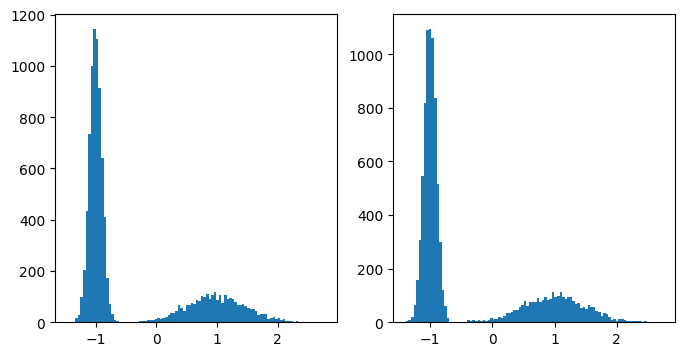

In [28]:
def gmm_2d_simulator(params, n_samples):
    """
    Simulates a batch of 2D data points from a 2-component GMM.
    
    Parameters:
    - params: dict with 'w1', 'mu1', 'mu2', 'sigma1', 'sigma2'
    - n_samples: your N_batch_size
    
    Returns:
    - data: numpy array of shape (N_batch_size, 2)
    """
    w1, mu1x,mu1y, mu2x,mu2y, sig1, sig2 = list(params)
    mu1 = np.array([mu1x, mu1y])
    mu2 = np.array([mu2x, mu2y])
    
    # Define covariance as sigma * I
    cov1 = (sig1**2) * np.eye(2)
    cov2 = (sig2**2) * np.eye(2)
    
    # 1. Decide which component each point in the batch belongs to
    # This ensures the overall batch reflects the mixing weight w1
    component_choices = np.random.choice([0, 1], size=n_samples, p=[w1, 1-w1])
    
    data = np.zeros((n_samples, 2))
    
    # 2. Vectorized sampling for each component
    # Narrow Mode
    mask1 = (component_choices == 0)
    if np.any(mask1):
        data[mask1] = np.random.multivariate_normal(mu1, cov1, size=np.sum(mask1))
        
    # Wide Mode
    mask2 = (component_choices == 1)
    if np.any(mask2):
        data[mask2] = np.random.multivariate_normal(mu2, cov2, size=np.sum(mask2))
    
    # data = data[np.argsort(np.linalg.norm(data,axis=1))]
    return data

# Example implementation for your project
# w1, mu1x, mu1y, mu2x, mu2y, sigma1, sigma2
true_params = [0.7,-1.0,-1.0,1.0,1.0,0.1,0.5]

sample_size = 10000
data = gmm_2d_simulator(true_params,sample_size)

fig,ax = plt.subplots(1,2,figsize = (8,4))
ax[0].hist(data[:,0],bins = 100);
ax[1].hist(data[:,1],bins = 100);

Running benchmarks...
Batch 10: 0.000204 sec
Batch 100: 0.000199 sec
Batch 1000: 0.000278 sec
Batch 5000: 0.000616 sec
Batch 10000: 0.001044 sec
Batch 50000: 0.004231 sec
Batch 100000: 0.009439 sec
Average increase in seconds per sample: 6.400467067848051e-08


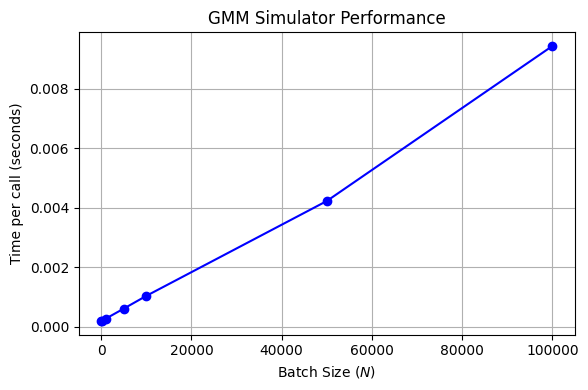

In [29]:
utils.benchmark_time([10, 100, 1000, 5000, 10000, 50000, 100000], lambda n: gmm_2d_simulator(true_params, n))

In [ ]:
#global estimation parameters
num_particles = 500
cores = 4


def gmm(p,Bi):
    """Model wrapper: simulate a batch matching the observed indices Bi and return (sim, obs)."""
    batch_size = Bi.shape[0]
    sim = gmm_2d_simulator(p,batch_size)
    obs = data[Bi,:]
    return sim, obs


def stats_func_gmm(x,k=5):
    """Summary statistics: mean k-NN distance (captures clustering/multimodality) plus per-axis moments (mean, var, covar, skew, kurtosis)."""
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(x)
    distances,_ = nbrs.kneighbors(x)
    mean_knn_dists = np.mean(distances[:,:k],axis=1)
    stats = np.stack([
        mean_knn_dists,
        x[:,0], x[:,1],          # Means
        x[:,0]**2, x[:,1]**2,    # Variances
        x[:,0] * x[:,1],         # Covariance
        x[:,0]**3, x[:,1]**3,    # Skewness (captures asymmetry of 2 modes)
        x[:,0]**4, x[:,1]**4     # Kurtosis (captures "narrowness" vs "wideness")
    ], axis=1)
    return stats

def stats_func(x,y,sf = stats_func_gmm):
    return sf(x), sf(y)

L = 2
prior = utils.uniform_prior([[0,1.0],
                             [-L,L],[-L,L],
                             [-L,L],[-L,L],
                             [0,1.0],[0,1.0]])


init_params = {
    'data':data,
    'model':gmm,
    'stats_func':stats_func,
    'prior':prior,
    'num_particles' : num_particles,
    'cores':cores
}


stats_func_gmm(data[:20]).shape

(20, 10)

### Constant minibatch SMC ABC

With the stats function as we have it, inferring $w_1$ is diffult, causing issues for the other parameters. Some other statistics can likely improve inference.

In [ ]:
est = schemes.constant_init(init_params,[1000])

threshold = np.inf
while threshold > 2:
    schemes.constant_loop(est)
    print('Proportion of shrinkage from prior: ',est.hdpr_marginal()[2] / np.diff(prior[1]).T)
    threshold = est.alpha_threshold

500
Generation: 1. Batch Size: 1000. Acceptance Rate: 1.000. Step time: 3.116. Total time 3.116. post-filter threshold: 10.6679. ESS: 500.00. Log HDPR vol: 4.675
Estimated v = 194.190. Noise: v/n = 0.194. v/N = 0.019. Estimated c = 0.039. SNR: eps^2 / (v/n) = 586.044. Time per sim: 0.003
[[0.92896362 0.84034986 0.86994376 0.8720448  0.85070315 0.90913222
  0.91487793]]
Generation: 2. Batch Size: 1000. Acceptance Rate: 0.672. Step time: 3.907. Total time 7.023. post-filter threshold: 5.5374. ESS: 443.62. Log HDPR vol: 4.310
Estimated v = 76.214. Noise: v/n = 0.076. v/N = 0.008. Estimated c = 0.047. SNR: eps^2 / (v/n) = 402.321. Time per sim: 0.003
[[0.92506267 0.80327965 0.83237011 0.78576371 0.78234194 0.88460065
  0.86481763]]
Generation: 3. Batch Size: 1000. Acceptance Rate: 0.413. Step time: 5.049. Total time 12.072. post-filter threshold: 3.8365. ESS: 430.64. Log HDPR vol: 4.054
Estimated v = 47.921. Noise: v/n = 0.048. v/N = 0.005. Estimated c = 0.054. SNR: eps^2 / (v/n) = 307.146

### Known heterogeneity

In this case, we assume we have identified classes depending on the cluster and use this information in the simulations, allowing for easier inference of $w_1$.

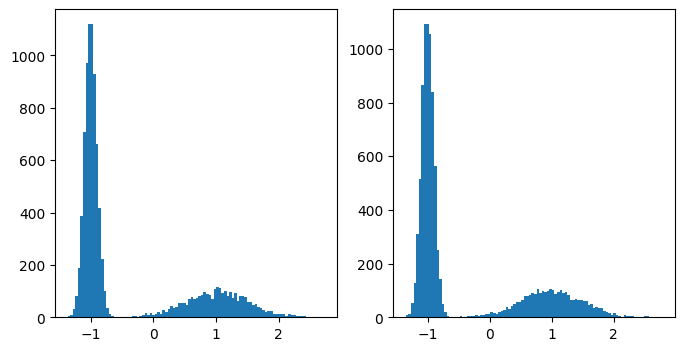

In [ ]:
def gmm_2d_simulator_het(params,classes):
    """Like gmm_2d_simulator, but the component assignment (classes) is given rather than sampled from w1."""
    mu1x,mu1y, mu2x,mu2y, sig1, sig2 = list(params)
    mu1 = np.array([mu1x, mu1y])
    mu2 = np.array([mu2x, mu2y])
    # Define covariance as sigma * I
    cov1 = (sig1**2) * np.eye(2)
    cov2 = (sig2**2) * np.eye(2)

    n_samples = classes.shape[0]
    data = np.zeros((n_samples, 2))

    mask1 = (classes == 0)
    if np.any(mask1):
        data[mask1] = np.random.multivariate_normal(mu1, cov1, size=np.sum(mask1))

    mask2 = (classes == 1)
    if np.any(mask2):
        data[mask2] = np.random.multivariate_normal(mu2, cov2, size=np.sum(mask2))

    return data


# Example implementation for your project
# mu1x, mu1y, mu2x, mu2y, sigma1, sigma2
true_params = [-1.0,-1.0,1.0,1.0,0.1,0.5]
w1 = 0.7

sample_size = 10000
classes = np.random.choice([0,1], size = sample_size, p=[w1, 1-w1])
data = gmm_2d_simulator_het(true_params,classes)

fig,ax = plt.subplots(1,2,figsize = (8,4))
ax[0].hist(data[:,0],bins = 100);
ax[1].hist(data[:,1],bins = 100);

In [ ]:
#global estimation parameters
num_particles = 500
cores = 4


def gmm(p,Bi):
    """Model wrapper for the known-heterogeneity case: uses the true class label per observation instead of sampling w1."""
    heterogeneity = classes[Bi]
    sim = gmm_2d_simulator_het(p,heterogeneity)
    obs = data[Bi,:]
    return sim, obs


def stats_func_gmm(x,k=5):
    """Same summary statistics as the no-heterogeneity case (mean k-NN distance + per-axis moments)."""
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(x)
    distances,_ = nbrs.kneighbors(x)
    mean_knn_dists = np.mean(distances[:,:k],axis=1)
    stats = np.stack([
        mean_knn_dists,
        x[:,0], x[:,1],          # Means
        x[:,0]**2, x[:,1]**2,    # Variances
        x[:,0] * x[:,1],         # Covariance
        x[:,0]**3, x[:,1]**3,    # Skewness (captures asymmetry of 2 modes)
        x[:,0]**4, x[:,1]**4     # Kurtosis (captures "narrowness" vs "wideness")
    ], axis=1)
    return stats

def stats_func(x,y,sf = stats_func_gmm):
    return sf(x), sf(y)

L = 2
prior = utils.uniform_prior([[-L,L],[-L,L],
                             [-L,L],[-L,L],
                             [0,1.0],[0,1.0]])


init_params = {
    'data':data,
    'model':gmm,
    'stats_func':stats_func,
    'prior':prior,
    'num_particles' : num_particles,
    'cores':cores
}


stats_func_gmm(data[:20]).shape

(20, 10)

In [19]:
est = schemes.constant_init(init_params,[1000])

for i in range(15):
    schemes.constant_loop(est)
    print(est.hdpr_marginal()[2] / np.diff(prior[1]).T)

500
Generation: 1. Batch Size: 1000. Acceptance Rate: 1.000. Step time: 1.766. Total time 1.766. post-filter threshold: 8.5444. ESS: 500.00. Log HDPR vol: 4.719
Estimated v = 129.418. Noise: v/n = 0.129. v/N = 0.013. Estimated c = 0.040. SNR: eps^2 / (v/n) = 564.122. Time per sim: 0.002
[[0.80998378 0.83970682 0.88909892 0.89087332 0.88687218 0.91624352]]
Generation: 2. Batch Size: 1000. Acceptance Rate: 0.672. Step time: 3.893. Total time 5.659. post-filter threshold: 4.7164. ESS: 463.22. Log HDPR vol: 4.286
Estimated v = 58.721. Noise: v/n = 0.059. v/N = 0.006. Estimated c = 0.049. SNR: eps^2 / (v/n) = 378.811. Time per sim: 0.003
[[0.7200893  0.69975436 0.85640557 0.82895273 0.89206963 0.88941265]]
Generation: 3. Batch Size: 1000. Acceptance Rate: 0.457. Step time: 4.544. Total time 10.203. post-filter threshold: 3.3781. ESS: 456.12. Log HDPR vol: 3.922
Estimated v = 36.336. Noise: v/n = 0.036. v/N = 0.004. Estimated c = 0.054. SNR: eps^2 / (v/n) = 314.057. Time per sim: 0.002
[[0.6

In [22]:
est = schemes.fvc_init(init_params,[20,None,1.0])

for i in range(15):
    schemes.fvc_loop(est)
    print(est.hdpr_marginal()[2] / np.diff(prior[1]).T)

500
Generation: 1. Batch Size: 20. Acceptance Rate: 1.000. Step time: 2.005. Total time 2.005. post-filter threshold: 8.2922. ESS: 500.00. Log HDPR vol: 4.712
Estimated v = 109.333. Noise: v/n = 5.467. v/N = 0.011. Estimated c = 0.282. SNR: eps^2 / (v/n) = 12.578. Time per sim: 0.002
Automatic c selection: c = 0.2816792825918882
New hyperparameter set: [20, np.float64(0.2816792825918882), 1.0]
Variance estimate: 5.477574353103826. C estimate: 0.0. V_total: 109.332821419238. batch size 20
[[0.8033271  0.82795868 0.90909557 0.89861993 0.87914249 0.90948113]]
Generation: 2. Batch Size: 20. Acceptance Rate: 0.653. Step time: 1.102. Total time 3.106. post-filter threshold: 4.8095. ESS: 462.46. Log HDPR vol: 4.489
Estimated v = 71.701. Noise: v/n = 3.585. v/N = 0.007. Estimated c = 0.393. SNR: eps^2 / (v/n) = 6.452. Time per sim: 0.001
Variance estimate: 1.8496580619077825. C estimate: 0.2281081969974935. V_total: 71.70055663116929. batch size 39
[[0.78759693 0.78537018 0.86582188 0.88189824

In [23]:
est = schemes.constant_init(init_params,[350])

for i in range(15):
    schemes.constant_loop(est)
    print(est.hdpr_marginal()[2] / np.diff(prior[1]).T)

500
Generation: 1. Batch Size: 350. Acceptance Rate: 1.000. Step time: 2.162. Total time 2.162. post-filter threshold: 11.6761. ESS: 500.00. Log HDPR vol: 4.686
Estimated v = 274.420. Noise: v/n = 0.784. v/N = 0.027. Estimated c = 0.074. SNR: eps^2 / (v/n) = 173.880. Time per sim: 0.002
[[0.81658637 0.78577278 0.89557086 0.90169283 0.89082621 0.91774428]]
Generation: 2. Batch Size: 350. Acceptance Rate: 0.687. Step time: 2.549. Total time 4.711. post-filter threshold: 6.0081. ESS: 464.98. Log HDPR vol: 4.272
Estimated v = 107.603. Noise: v/n = 0.307. v/N = 0.011. Estimated c = 0.091. SNR: eps^2 / (v/n) = 117.412. Time per sim: 0.002
[[0.74258631 0.70779065 0.83919939 0.82655606 0.86331998 0.88953693]]
Generation: 3. Batch Size: 350. Acceptance Rate: 0.443. Step time: 3.041. Total time 7.752. post-filter threshold: 4.0486. ESS: 460.29. Log HDPR vol: 3.886
Estimated v = 56.263. Noise: v/n = 0.161. v/N = 0.006. Estimated c = 0.097. SNR: eps^2 / (v/n) = 101.967. Time per sim: 0.001
[[0.714